
# Evaluación 1

**Autores**: Felipe Ahumada Silva - Francisca Carrasco Lozano

**Fecha de Creación**: Abril 2026


In [234]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder

from pathlib import Path

In [235]:
# Carga el set de datos

url_dataset = "https://raw.githubusercontent.com/francarrascoo/Programacion-para-la-ciencia-de-datos/refs/heads/main/data/dataset_clientes.csv"

data = pd.read_csv(url_dataset)

data.head()

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1


In [236]:
# Configura rutas de salida para visualizaciones y reportes
cwd = Path.cwd()
repo_root = cwd if (cwd / "outputs").exists() else cwd.parent

outputs_dir = repo_root / "outputs"
visualizaciones_dir = outputs_dir / "visualizaciones"
reportes_dir = outputs_dir / "reportes_generados"

visualizaciones_dir.mkdir(parents=True, exist_ok=True)
reportes_dir.mkdir(parents=True, exist_ok=True)

def guardar_figura(fig, nombre_archivo: str, dpi: int = 300) -> Path:
    """Guarda una figura de Matplotlib en outputs/visualizaciones."""
    ruta = visualizaciones_dir / f"{nombre_archivo}.png"
    fig.savefig(ruta, dpi=dpi, bbox_inches="tight")
    return ruta

# Configura rutas de salida para data procesada
data_procesada_dir = repo_root / "data" / "dataset_clientes_procesado.csv"
data_procesada_dir.parent.mkdir(parents=True, exist_ok=True)


## Revisión del estado

In [237]:
# Cantidad de observaciones y columnas
data.shape

(20400, 22)

### Valores faltantes y tipos de datos

In [238]:
# Tipos de datos y cantidad de valores no nulos por columna
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  object 
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  object 
 4   region                 20400 non-null  object 
 5   estado_civil           20400 non-null  object 
 6   ingreso_mensual        19379 non-null  float64
 7   gasto_mensual          19375 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  object 
 14  tipo_plan              20400 non-null  object 
 15  nu

### Existencia de duplicados

In [239]:
# Revisa la existencia de duplicados
data.duplicated().sum()

np.int64(400)

In [240]:
# Obtiene los registros duplicados
data[data.duplicated(keep=False)].sort_values(by='id_cliente')

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
20032,178,2022-02-16,58,Otro,Centro,Soltero,574734.320058,124060.694605,1.567047e+06,706.773275,...,133,Alto,Premium,2,0,Tienda,Sabado,11,8146,1
177,178,2022-02-16,58,Otro,Centro,Soltero,574734.320058,124060.694605,1.567047e+06,706.773275,...,133,Alto,Premium,2,0,Tienda,Sabado,11,8146,1
215,216,2021-05-23,77,Femenino,Centro,Divorciado,696251.283767,755824.522948,2.522168e+06,691.380909,...,217,Alto,Estandar,5,1,App,Sabado,6,4541,1
20300,216,2021-05-23,77,Femenino,Centro,Divorciado,696251.283767,755824.522948,2.522168e+06,691.380909,...,217,Alto,Estandar,5,1,App,Sabado,6,4541,1
20348,327,2019-07-15,43,Femenino,Sur,Soltero,611018.691110,238932.156632,8.764364e+05,618.183493,...,303,Medio,Basico,3,0,App,Lunes,11,6291,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19921,19922,2020-01-22,52,Masculino,Sur,Casado,892522.042338,161697.180367,1.750559e+06,662.274443,...,274,Bajo,Premium,1,0,App,Viernes,3,4398,1
19923,19924,2018-01-17,54,Otro,Centro,Casado,822109.701169,489936.535727,2.022070e+06,584.830157,...,145,Bajo,Estandar,1,0,Tienda,Miercoles,17,8097,1
20289,19924,2018-01-17,54,Otro,Centro,Casado,822109.701169,489936.535727,2.022070e+06,584.830157,...,145,Bajo,Estandar,1,0,Tienda,Miercoles,17,8097,1
20147,19983,2022-02-17,26,Otro,Centro,Soltero,947809.404071,221838.916723,3.226056e+06,556.285263,...,361,Alto,Basico,1,1,Tienda,Jueves,5,6118,1


## Análisis de duplicados

En el contexto de este negocio de servicios digitales por suscripción, es esperable que el ID de un cliente aparezca múltiples veces si existen registros de distintas fechas o se evalúan los distintos productos contratados.

Sin embargo, la instrucción ```data.duplicated().sum()``` está detectando 400 filas donde las 22 columnas son exactamente idénticas. La tabla muestra que los registros duplicados tienen exactamente los mismos montos con decimales en variables como el ```ingreso_mensual``` y el ```gasto_mensual```, además de coincidir al milímetro en las fechas y horas de registro.

Por lo que estas serán eliminadas en procesos posteriores.

### Existencia de valores atípicos (outliers)

Existen 3 métodos principales para detectar outliers, cuyo uso depende de la situación:

1. **Regla de los 3 sigmas (método univariado):** Se basa en la distribución normal. Valores fuera del rango [media - 3σ, media + 3σ] se consideran atípicos. Es adecuado **solo cuando los datos siguen una distribución aproximadamente normal**.

2. **IQR - Rango Intercuartílico (método univariado):** Usa los cuartiles Q1 y Q3 para definir los límites [Q1 - 1.5·IQR, Q3 + 1.5·IQR]. Es más robusto que la regla de los 3 sigmas y **no requiere supuesto de normalidad**, haciéndolo adecuado para distribuciones sesgadas.

3. **Local Outlier Factor - LOF (método multivariado):** Detecta outliers considerando la densidad local de los datos respecto a sus vecinos. Es útil cuando los **outliers dependen de la interacción entre múltiples variables** simultáneamente.

#### Selección del método y de variables a tratar

Primero se revisan las variables numéricas (con valor de negocio) del dataset y luego, con base en esa evidencia, se seleccionan las variables que requieren tratamiento.

In [241]:
# Muestra medidas estadísticas de las variables numéricas (excluyendo id_cliente, tiene_tarjeta_credito y codigo_postal)
data.drop(columns=['id_cliente', 'tiene_tarjeta_credito', 'codigo_postal']).describe()

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono
count,20400.00000,1.937900e+04,19375.000000,2.040000e+04,19379.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000
mean,48.54598,8.330390e+05,399453.495188,2.061953e+06,600.441593,60.205882,9.966765,182.325686,2.994853,11.416716,0.396814
std,17.84971,4.301978e+05,150831.135171,1.055155e+06,100.408685,34.210052,5.460586,105.056827,1.410716,6.891420,0.489249
min,18.00000,-8.302577e+04,-194957.467079,-1.684124e+06,220.516968,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,33.00000,6.346396e+05,296753.420113,1.461942e+06,532.872163,31.000000,5.000000,92.000000,2.000000,6.000000,0.000000
50%,48.00000,8.044483e+05,398887.260180,2.017759e+06,600.955064,61.000000,10.000000,181.000000,3.000000,11.000000,0.000000
75%,64.00000,9.737937e+05,500485.426137,2.557871e+06,668.245607,90.000000,15.000000,274.000000,4.000000,17.000000,1.000000
max,79.00000,7.560936e+06,954575.217321,1.777694e+07,998.290682,119.000000,19.000000,364.000000,5.000000,23.000000,1.000000


In [242]:
# Diagnóstico completo de las variables numéricas (excluyendo id_cliente, tiene_tarjeta_credito, codigo_postal)
numeric_cols_all = data.select_dtypes(include=[np.number]).columns.tolist() 
numeric_cols_analisis = [col for col in numeric_cols_all if col != "id_cliente" and col != "tiene_tarjeta_credito" and col != "codigo_postal"]

resumen_numericas = []
for col in numeric_cols_analisis:
    serie = data[col].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out = ((serie < lim_inf) | (serie > lim_sup)).sum()

    resumen_numericas.append(
        {
            "variable": col, # Nombre de la columna a analizar.
            "missing_%": data[col].isna().mean() * 100, # Calcula el porcentaje exacto de datos faltantes (nulos o NaN) en esa columna.
            "skewness": serie.skew(), # Mide la asimetría (skewness) de la distribución de tus datos.
            "n_outliers_iqr": int(n_out), # La cantidad total de valores atípicos (outliers) detectados en esa columna.
            "pct_outliers_iqr": (n_out / len(serie) * 100) if len(serie) else np.nan, # El porcentaje que representan esos valores atípicos respecto al total de registros de la columna.
            "min": serie.min(), 
            "max": serie.max(),
        }
    )

resumen_numericas = pd.DataFrame(resumen_numericas).sort_values(
    by="pct_outliers_iqr", ascending=False
)


resumen_numericas.round(3)

,variable,missing_%,skewness,n_outliers_iqr,pct_outliers_iqr,min,max
1,ingreso_mensual,5.005,6.074,313,1.615,-83025.772,7.560936e+06
3,deuda_total,0.000,3.407,309,1.515,-1684123.654,1.777694e+07
4,score_crediticio,5.005,-0.017,131,0.676,220.517,9.982910e+02
2,gasto_mensual,5.025,0.011,126,0.650,-194957.467,9.545752e+05
0,edad,0.000,-0.002,0,0.000,18.000,7.900000e+01
5,antiguedad_meses,0.000,-0.013,0,0.000,1.000,1.190000e+02
6,frecuencia_compra,0.000,0.005,0,0.000,1.000,1.900000e+01
7,ultima_compra_dias,0.000,0.011,0,0.000,1.000,3.640000e+02
8,num_productos,0.000,0.008,0,0.000,1.000,5.000000e+00
9,hora_registro,0.000,0.013,0,0.000,0.000,2.300000e+01


## Análisis de outliers

Podemos ver datos inconsistentes en algunas columnas.

```ingreso_mensual``` tiene datos negativos, lo cual es inconsistente con el contexto del negocio.

Lo mismo sucede con ```gasto_mensual``` y ```deuda_total```.



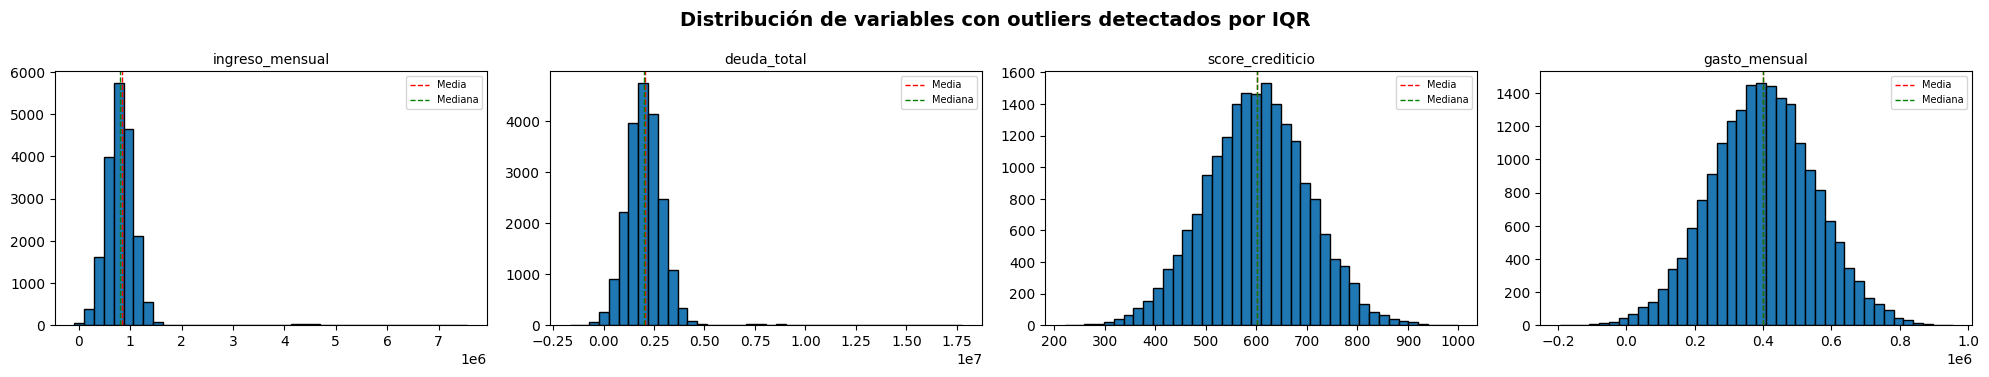

In [243]:
# Análisis visual solo de variables con outliers detectados por IQR
variables_con_outliers = (
    resumen_numericas.loc[resumen_numericas["n_outliers_iqr"] > 0, "variable"]
    .tolist()
)

if len(variables_con_outliers) == 0:
    print("IQR no detectó outliers en las variables numéricas.")
else:
    n_cols = 4
    n_rows = int(np.ceil(len(variables_con_outliers) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(variables_con_outliers):
        serie = data[col].dropna()
        axes[i].hist(serie, bins=40, edgecolor="black")
        axes[i].axvline(serie.mean(), color="red", linestyle="--", linewidth=1, label="Media")
        axes[i].axvline(serie.median(), color="green", linestyle="--", linewidth=1, label="Mediana")
        axes[i].set_title(col, fontsize=10)
        axes[i].legend(fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(
        "Distribución de variables con outliers detectados por IQR",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    guardar_figura(fig, "histogramas_variables_con_outliers_iqr")
    plt.show()

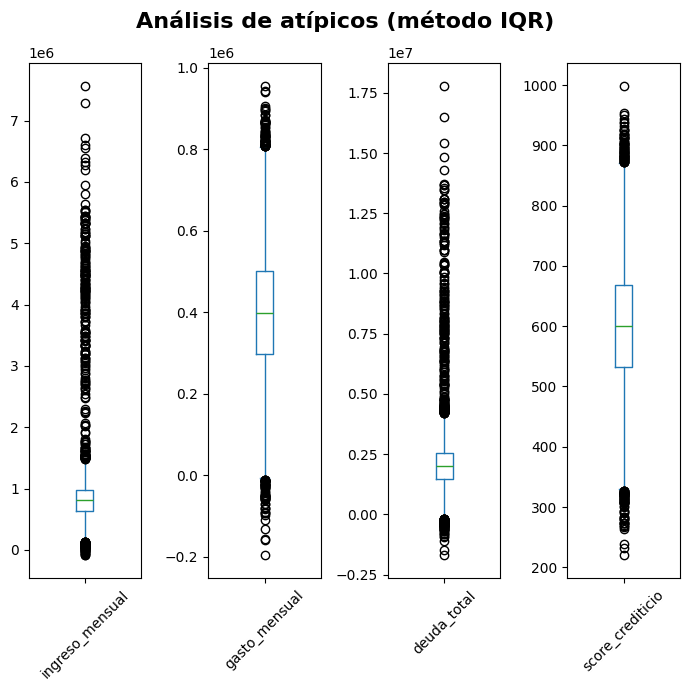

In [244]:
# Visualización de atípicos con boxplots (basados en IQR)
revision_atipicos = ["ingreso_mensual", "gasto_mensual", "deuda_total", "score_crediticio"]
fig, axes = plt.subplots(1, 4, figsize=(20, 20))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos):
    data[col].plot(kind='box', figsize=(7, 7), ax=axes[i])
    axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos (método IQR)", fontsize=16, fontweight="bold")
plt.tight_layout()

guardar_figura(fig, "boxplots_atipicos_iqr")

plt.show()

### Estadísticas antes de la limpieza

In [245]:
# Diagnóstico completo de las variables categóricas
data.describe(include="object")

,fecha_registro,genero,region,estado_civil,uso_app,tipo_plan,canal_registro,dia_semana_registro
count,20400,20400,20400,20400,20400,20400,20400,20400
unique,2000,3,3,3,3,3,3,7
top,2022-04-09,Otro,Sur,Casado,Bajo,Estandar,App,Miercoles
freq,21,6997,6812,6828,6886,6878,6894,3000


In [246]:
for col in data.select_dtypes(include="object").columns:
    print(f"Columna: {col}")
    print(data[col].unique())

Columna: fecha_registro
['2021-10-27' '2018-08-25' '2019-05-25' ... '2021-11-05' '2018-10-20'
 '2021-06-02']
Columna: genero
['Otro' 'Masculino' 'Femenino']
Columna: region
['Norte' 'Centro' 'Sur']
Columna: estado_civil
['Divorciado' 'Soltero' 'Casado']
Columna: uso_app
['Bajo' 'Medio' 'Alto']
Columna: tipo_plan
['Estandar' 'Premium' 'Basico']
Columna: canal_registro
['Tienda' 'App' 'Web']
Columna: dia_semana_registro
['Lunes' 'Martes' 'Jueves' 'Domingo' 'Sabado' 'Miercoles' 'Viernes']


## Pipeline: Limpieza + Transformación

En esta sección se ejecuta todo el flujo en un solo pipeline:
1. Eliminación de duplicados
2. Feature engineering
3. Limpieza (winsorización e imputación)
4. Transformación (escalado y codificación)

In [247]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """
    Tratamiento de atípicos

    Parámetros
    ----------
    BaseEstimator : Clase base para estimadores en scikit-learn.
    TransformerMixin : Clase base para transformadores en scikit-learn.

    Atributos
    ---------
    columns_ : array-like
        Nombres de las columnas a transformar.
    limits : tuple
        % de los extremos a descartar
    """
    def __init__(self, limits=(0.01, 0.01)):
        self.limits = limits

    def fit(self, X, y=None):
        # Guardar nombres si es DataFrame, si no generar nombres genéricos
        if isinstance(X, pd.DataFrame):
            self.columns_ = X.columns
        else:
            self.columns_ = np.arange(X.shape[1])
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_)
        for col in self.columns_:
            lower = X[col].quantile(self.limits[0])
            upper = X[col].quantile(1 - self.limits[1])
            X = X.astype("float64")
            X[col] = np.clip(X[col], lower, upper)
        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array(self.columns_)
        else:
            return np.array(input_features)

In [248]:
def eliminar_duplicados(X: pd.DataFrame) -> pd.DataFrame:
    return X.drop_duplicates()

def tratar_inconsistencias(X: pd.DataFrame) -> pd.DataFrame:
    """Corrige inconsistencias en las variables."""
    X = X.copy()

    # Reemplazar valores negativos en ingreso_mensual, gasto_mensual y deuda_total por NaN
    for col in ["ingreso_mensual", "gasto_mensual", "deuda_total"]:
        X.loc[X[col] < 0, col] = np.nan

    return X

def agregar_variables_clientes(X: pd.DataFrame) -> pd.DataFrame:
    """Agrega variables derivadas para la etapa de transformación."""
    X = X.copy()
    eps = 1e-9

    # Se crean nuevas variables basadas en las existentes para capturar relaciones importantes:
    X["ratio_gasto"] = X["gasto_mensual"] / (X["ingreso_mensual"] + eps)
    X["ratio_deuda_ingreso"] = X["deuda_total"] / (X["ingreso_mensual"] + eps)
    X["margen_ingreso"] = X["ingreso_mensual"] - X["gasto_mensual"]

    X["segmento_score"] = pd.cut(
        X["score_crediticio"],
        bins=[-np.inf, 500, 650, np.inf],
        labels=["Bajo", "Medio", "Alto"]
    )

    return X


Se crea ratio_gasto, ratio_deuda_ingreso, margen_ingreso, segmento_score.

In [249]:
# Variables que se usarán en el pipeline
numeric_features = [
    "ingreso_mensual", "gasto_mensual", "deuda_total", "score_crediticio",
    "ratio_gasto", "ratio_deuda_ingreso", "margen_ingreso"
]

# Categóricas nominales (sin orden natural) -> OneHotEncoder
categorical_nominal_features = [
    "genero", "region", "estado_civil", "canal_registro", "dia_semana_registro"
]

# Categóricas ordinales (con orden) -> OrdinalEncoder
categorical_ordinal_features = ["uso_app", "tipo_plan", "segmento_score"]

ordinal_categories = [
    ["Bajo", "Medio", "Alto"],          # uso_app
    ["Basico", "Estandar", "Premium"], # tipo_plan
    ["Bajo", "Medio", "Alto"]           # segmento_score
]

In [250]:
# Define dos pipelines numericos: uno para visualizacion y otro para modelado
pipeline_numerico_viz = Pipeline(
    steps=[
        ("winsorizer", Winsorizer()),
        ("imputacion", SimpleImputer(strategy="median"))
    ]
)

pipeline_numerico_modelo = Pipeline(
    steps=[
        ("winsorizer", Winsorizer()),
        ("imputacion", SimpleImputer(strategy="median")),
        ("escalado", StandardScaler())
    ]
)

In [251]:
# Define el pipeline para las variables categóricas nominales
pipeline_categorico_nominal = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("codificacion", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

# Define el pipeline para las variables categóricas ordinales
pipeline_categorico_ordinal = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("codificacion", OrdinalEncoder(categories=ordinal_categories, handle_unknown="use_encoded_value", unknown_value=-1))
    ]
)

Se separan en **dos pipelines categóricos** para respetar la naturaleza de cada variable y evitar introducir relaciones numéricas artificiales en variables nominales.

- **Nominales** (sin orden natural): `genero`, `region`, `estado_civil`, `canal_registro`, `dia_semana_registro` -> **OneHotEncoder**
- **Ordinales** (con orden): `uso_app` (Bajo < Medio < Alto), `tipo_plan` (Básico < Estándar < Premium), `segmento_score` -> **OrdinalEncoder**

In [252]:
# Integra todos los pipelines para visualizacion (sin scaler)
preprocesador_viz = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico_viz, numeric_features),
        ("cat_nom", pipeline_categorico_nominal, categorical_nominal_features),
        ("cat_ord", pipeline_categorico_ordinal, categorical_ordinal_features)
    ]
)

# Integra todos los pipelines para modelado (con scaler)
preprocesador_modelo = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico_modelo, numeric_features),
        ("cat_nom", pipeline_categorico_nominal, categorical_nominal_features),
        ("cat_ord", pipeline_categorico_ordinal, categorical_ordinal_features)
    ]
)

In [253]:
# Define dos pipelines finales: visualizacion y modelado
pipeline_viz = Pipeline(
    steps=[
        ("duplicados", FunctionTransformer(eliminar_duplicados, validate=False)),
        ("inconsistencias", FunctionTransformer(tratar_inconsistencias, validate=False)),
        ("feature_engineering", FunctionTransformer(agregar_variables_clientes, validate=False)),
        ("preprocesamiento", preprocesador_viz)
    ]
)

pipeline_modelo = Pipeline(
    steps=[
        ("duplicados", FunctionTransformer(eliminar_duplicados, validate=False)),
        ("inconsistencias", FunctionTransformer(tratar_inconsistencias, validate=False)),
        ("feature_engineering", FunctionTransformer(agregar_variables_clientes, validate=False)),
        ("preprocesamiento", preprocesador_modelo)
    ]
)

In [254]:
# Aplica ambos pipelines
data_limpia_viz_np = pipeline_viz.fit_transform(data)
data_modelo_np = pipeline_modelo.fit_transform(data)

In [255]:
# Crea DataFrame para visualizacion (sin scaler)
data_limpia_viz = pd.DataFrame(
    data_limpia_viz_np,
    columns=pipeline_viz.named_steps["preprocesamiento"].get_feature_names_out()
)

# Crea DataFrame para modelado (con scaler)
data_modelo = pd.DataFrame(
    data_modelo_np,
    columns=pipeline_modelo.named_steps["preprocesamiento"].get_feature_names_out()
)

# Limpia prefijos de nombres de columnas
data_limpia_viz.columns = data_limpia_viz.columns.str.replace(r"^(num|cat_nom|cat_ord)__", "", regex=True)
data_modelo.columns = data_modelo.columns.str.replace(r"^(num|cat_nom|cat_ord)__", "", regex=True)

# Asegura tipo numerico en columnas numericas
data_limpia_viz[numeric_features] = data_limpia_viz[numeric_features].apply(pd.to_numeric)
data_modelo[numeric_features] = data_modelo[numeric_features].apply(pd.to_numeric)

# DataFrame final para efectos de modelado
data_procesada = data_modelo.copy()

In [256]:
data_procesada.head()

,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,ratio_gasto,ratio_deuda_ingreso,margen_ingreso,genero_Femenino,genero_Masculino,genero_Otro,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,uso_app,tipo_plan,segmento_score
0,0.446717,0.862431,0.504233,-1.508560,0.039827,-0.127621,-0.036458,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2.247143,-0.605235,-0.518958,-0.264740,-1.049522,-0.921528,2.289547,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,1.0
2,-0.020820,-0.095102,2.902513,1.769467,-0.186233,-0.197974,-0.012968,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0
3,-1.459383,0.115690,1.185727,-1.640425,1.283377,2.136783,-1.357503,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0
4,-0.270705,0.630720,-0.497765,-1.375678,0.346357,-0.362883,-0.558162,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [257]:
data_procesada.shape

(20000, 29)

In [ ]:
# Tipo plan - Antes del preprocesamiento
data.tipo_plan.value_counts()

tipo_plan
Estandar    6878
Premium     6862
Basico      6660
Name: count, dtype: int64

In [ ]:
# Tipo plan - Después del preprocesamiento (OrdinalEncoder) 
# Sin datos duplicados
data_procesada.tipo_plan.value_counts()

tipo_plan
2.0    6744
1.0    6733
0.0    6523
Name: count, dtype: int64

### Estadísticas después del pipeline

In [ ]:
# Estadísticas descriptivas de las variables numéricas después de limpieza (sin scaler)
data_limpia_viz.describe()

,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,ratio_gasto,ratio_deuda_ingreso,margen_ingreso,genero_Femenino,genero_Masculino,genero_Otro,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,uso_app,tipo_plan,segmento_score
count,2.000000e+04,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,8.100772e+05,400788.748536,2.040312e+06,600.513590,0.554575,2.886265,4.107224e+05,0.331050,0.326000,0.342950,...,0.142000,0.143350,0.143100,0.143350,0.146700,0.140150,0.141350,0.995350,1.011050,1.144600
std,2.557132e+05,142971.097446,8.088387e+05,96.191454,0.312170,1.862078,2.881448e+05,0.470603,0.468759,0.474707,...,0.349059,0.350438,0.350184,0.350438,0.353815,0.347151,0.348391,0.818695,0.814408,0.652696
min,2.254320e+05,64942.712971,2.852431e+05,367.174939,0.066926,0.305379,-2.707366e+05,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.453338e+05,304440.766520,1.481319e+06,537.297541,0.366567,1.779790,2.339867e+05,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,8.047533e+05,399466.390062,2.022973e+06,601.094894,0.496440,2.517631,4.069857e+05,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,9.637240e+05,494276.114367,2.557054e+06,663.982755,0.660419,3.443144,5.747962e+05,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,2.000000
max,1.762383e+06,753339.900324,4.387918e+06,832.804913,2.007407,12.418866,1.460907e+06,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000


In [ ]:
# Revisión de categóricas post-transformación
columnas_categoricas = data_procesada.select_dtypes(include=["object", "category"]).columns

if len(columnas_categoricas) == 0:
    print("No hay columnas categóricas tipo object/category después del pipeline.")
    # Esto es esperado cuando OneHotEncoder deja todo en formato numérico
else:
    display(data_procesada[columnas_categoricas].describe())

No hay columnas categóricas tipo object/category después del pipeline.


### Comparación visual

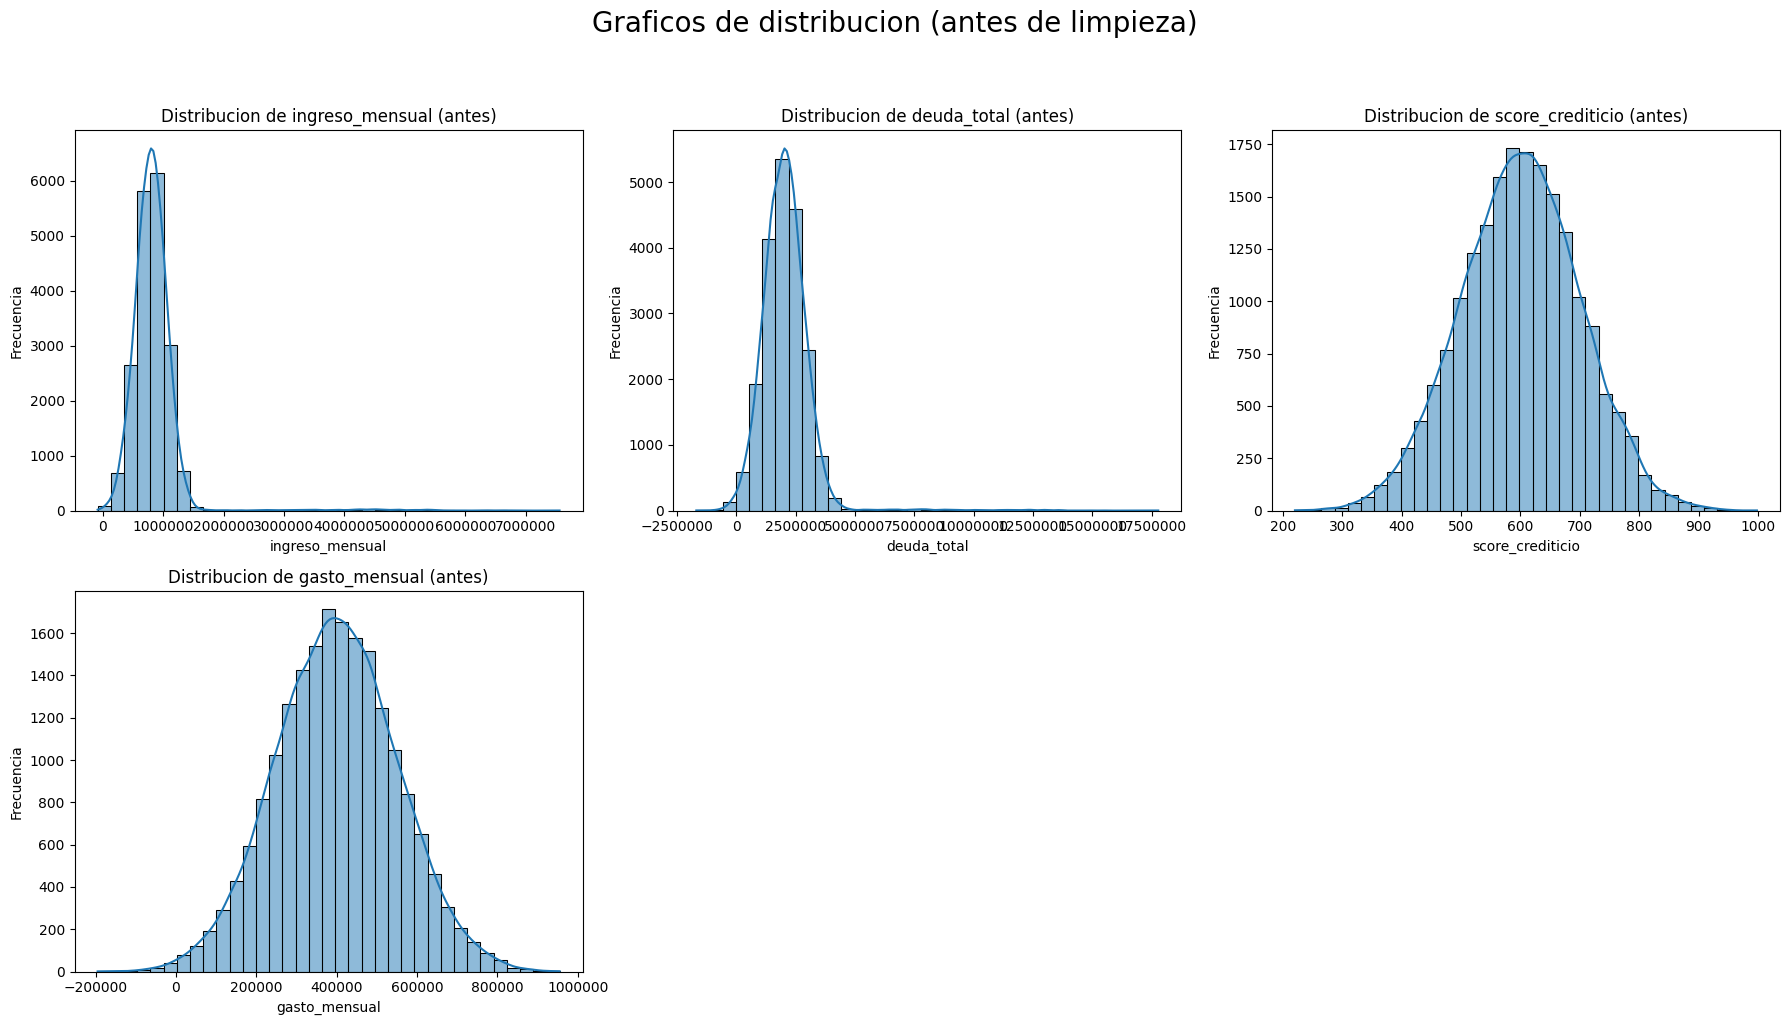

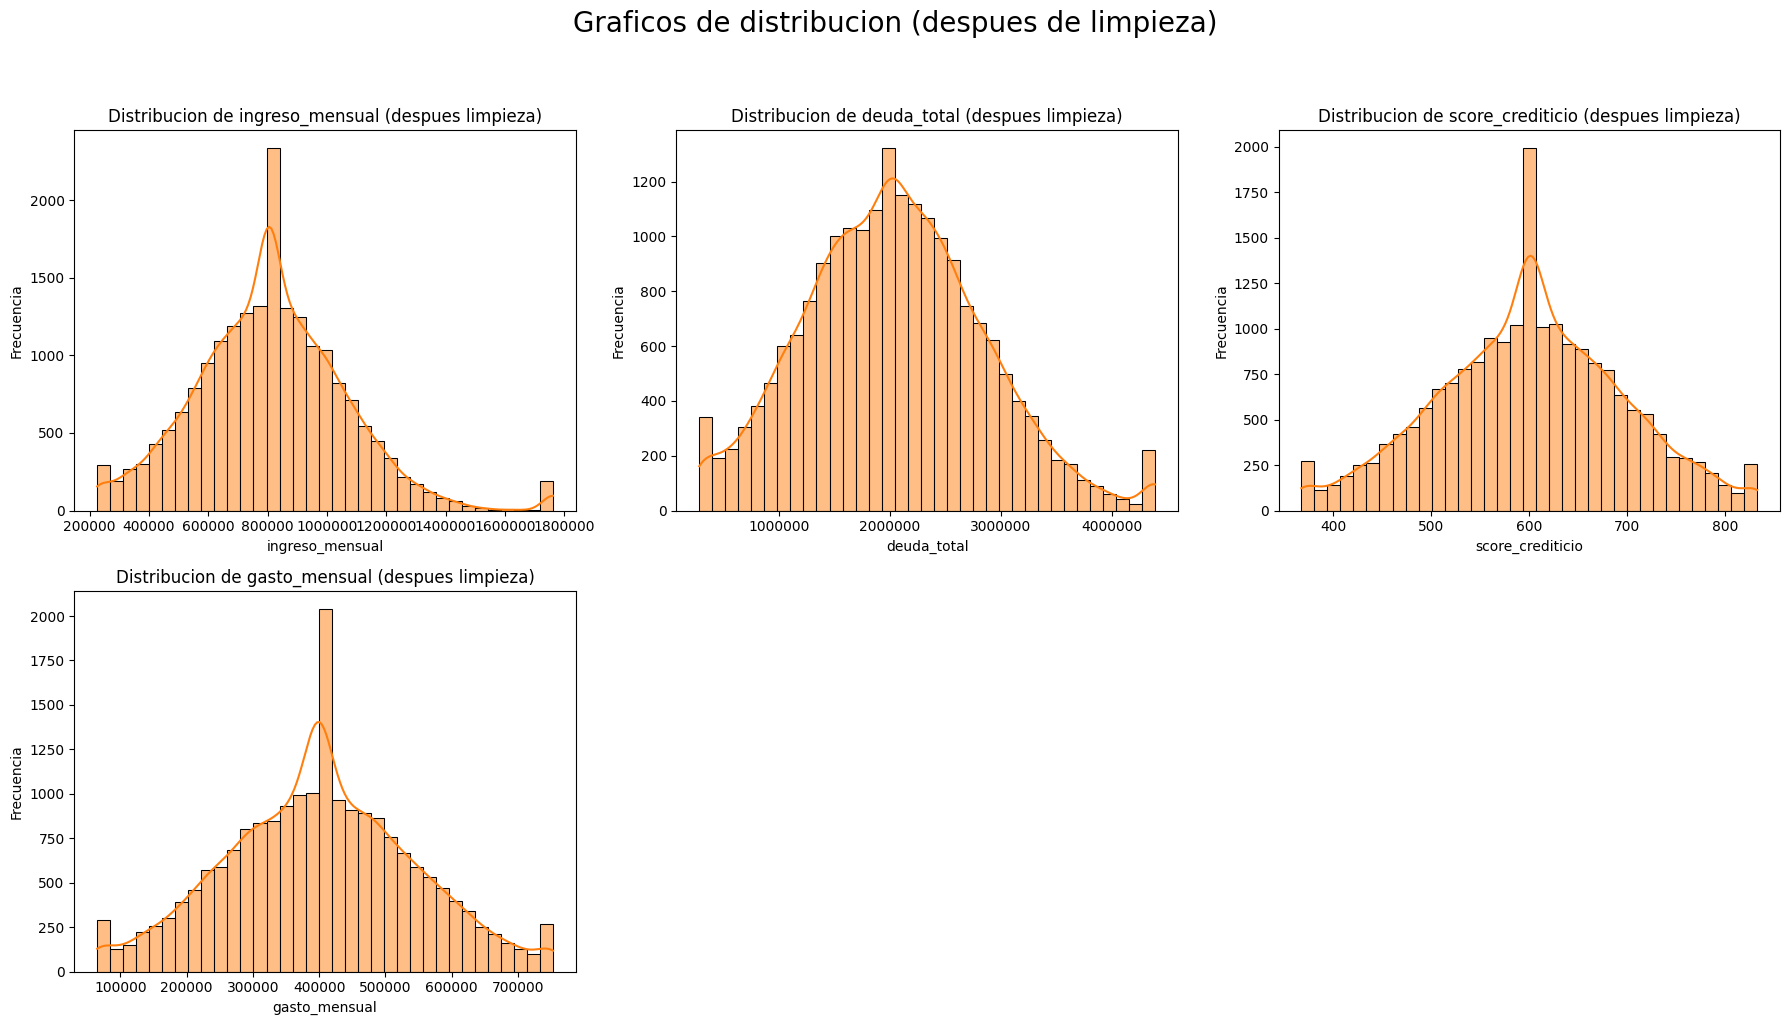

In [263]:
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

# Graficos antes y despues de limpieza
cols = [c for c in variables_con_outliers if c in data.columns and c in data_limpia_viz.columns]

if len(cols) == 0:
    print("No hay variables comparables.")
else:
    num_cols = 3
    num_columns = len(cols)
    num_rows = (num_columns + num_cols - 1) // num_cols

    # Antes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 5))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cols):
        sns.histplot(data[col].dropna(), kde=True, bins=35, ax=axes[i])
        axes[i].set_title(f"Distribucion de {col} (antes)")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frecuencia")
        axes[i].ticklabel_format(style="plain", axis="x", useOffset=False)
        axes[i].xaxis.set_major_formatter(ScalarFormatter())
        axes[i].xaxis.get_major_formatter().set_scientific(False)

    for j in range(num_columns, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Graficos de distribucion (antes de limpieza)", fontsize=20, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    guardar_figura(fig, "comparacion_distribucion_antes_limpieza")
    plt.show()

    # Despues de limpieza (sin scaler)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 5))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cols):
        sns.histplot(data_limpia_viz[col].dropna(), kde=True, bins=35, ax=axes[i], color="tab:orange")
        axes[i].set_title(f"Distribucion de {col} (despues limpieza)")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frecuencia")
        axes[i].ticklabel_format(style="plain", axis="x", useOffset=False)
        axes[i].xaxis.set_major_formatter(ScalarFormatter())
        axes[i].xaxis.get_major_formatter().set_scientific(False)

    for j in range(num_columns, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Graficos de distribucion (despues de limpieza)", fontsize=20, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    guardar_figura(fig, "comparacion_distribucion_despues_limpieza")
    plt.show()

### Exportación de datos procesados

In [264]:
# Guarda el dataset procesado
data_procesada.to_csv(data_procesada_dir, index=False, encoding="utf-8")